# 04 - NASA C-MAPSS RUL IPMEF Updated

This notebook implements the temporal Remaining Useful Life stage of the research using NASA C-MAPSS FD001.

## Research role

- **RQ1:** compare conventional RUL evaluation with a broader deployment-oriented baseline assessment.
- **RQ2:** quantify retention under controlled temporal sensor-data degradation.
- **RQ3:** identify Pareto-efficient RUL models and apply constraint-based scenario selection.
- Prepare reproducible processed arrays and metadata for Notebook 5 anomaly-triggered prognostics.

## Important boundaries

- FD001 contains one operating condition and one fault mode.
- Reported latency is measured in the current software environment, not certified edge hardware.
- The composite corruption-robustness score is an adapted summary; condition-level results remain primary.
- Robustness corruptions operate on standardised windows. A zero replacement therefore represents the training mean.
- Scenario constraints are experimental parameters derived from observed candidate ranges, not real factory requirements.

In [ ]:
# Install required package
!pip -q install numpy pandas matplotlib scipy scikit-learn xgboost tensorflow joblib psutil

In [ ]:
# Import libraries

import os, sys, json, time, random, shutil, zipfile, urllib.request, platform, tempfile, warnings
from pathlib import Path
import joblib, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

# Scikit-learn utilities
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Model
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")

In [ ]:
# Output directories
FD = "FD001"
OUT = Path("cmapss_rul_ipmef_outputs")
FIG = OUT / "figures"
MOD = OUT / "models"
PROCESSED = OUT / "processed"

for directory in [OUT, FIG, MOD, PROCESSED]:
    directory.mkdir(parents=True, exist_ok=True)

# Experiment configuration
WINDOW = 30
RUL_CAP = 125
PRIMARY_SEED = 42


MODEL_SEEDS = [PRIMARY_SEED]   # multi-seed extension placeholder
VALIDATION_FRACTION = 0.20
CORRUPTION_REPEATS = 5
LATENCY_WARMUPS = 5
LATENCY_REPEATS = 30
SINGLE_SAMPLE_LATENCY_REPEATS = 100

DATA_URL = (
    "https://phm-datasets.s3.amazonaws.com/NASA/"
    "6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
)

ZIP_PATH = Path("CMAPSSData.zip")
DATA_DIR = Path("CMAPSSData")

print("Output directory:", OUT.resolve())

Output directory: /content/cmapss_rul_ipmef_outputs


In [ ]:
# Global seed for reproducibility
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_global_seed(PRIMARY_SEED)

In [ ]:
# Save environment metadata
environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "logical_cpu_count": psutil.cpu_count(logical=True),
    "physical_cpu_count": psutil.cpu_count(logical=False),
    "ram_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "tensorflow_version": tf.__version__,
}

# Experiment configuration
experiment_configuration = {
    "dataset": FD,
    "window_length": WINDOW,
    "rul_cap": RUL_CAP,
    "primary_seed": PRIMARY_SEED,
    "model_seeds": MODEL_SEEDS,
    "validation_fraction_by_engine": VALIDATION_FRACTION,
    "corruption_repeats": CORRUPTION_REPEATS,
    "latency_warmups": LATENCY_WARMUPS,
    "latency_repeats": LATENCY_REPEATS,
    "single_sample_latency_repeats": SINGLE_SAMPLE_LATENCY_REPEATS,
    "data_url": DATA_URL,
    "interpretation": {
        "latency": "Comparative software-level timing in the recorded environment.",
        "robustness": "Adapted corruption-robustness summary; condition-level evidence remains primary.",
        "constraints": "Experimental values derived from observed candidate ranges.",
    },
}

with open(OUT / "execution_environment.json", "w", encoding="utf-8") as file:
    json.dump(environment, file, indent=2)

with open(OUT / "experiment_configuration.json", "w", encoding="utf-8") as file:
    json.dump(experiment_configuration, file, indent=2)

display(pd.DataFrame([environment]).T.rename(columns={0: "Value"}))

,Value
python_version,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
processor,x86_64
logical_cpu_count,2
physical_cpu_count,1
ram_gb,12.67
numpy_version,2.0.2
pandas_version,2.2.2
tensorflow_version,2.20.0


## Download, Extract and Locate C‑MAPSS FD001

This section ensures that the NASA C‑MAPSS FD001 dataset is available for processing.  
The workflow is:

1. Check whether the outer ZIP archive exists locally.  
2. If not, download it from the official PHM Society S3 bucket.  
3. Extract the outer archive.  
4. Locate and extract the inner CMAPSSData.zip archive.  
5. Identify the required FD001 files:
   - train_FD001.txt
   - test_FD001.txt
   - RUL_FD001.txt

This step guarantees that the dataset is correctly structured before feature extraction, window generation, and model training.


In [ ]:
# Download outer ZIP if not present
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(DATA_DIR)

print("Outer ZIP extracted to:", DATA_DIR.resolve())

# Extract outer ZIP
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(DATA_DIR)

print("Outer ZIP extracted to:", DATA_DIR.resolve())

Download completed: /content/CMAPSSData.zip
Outer ZIP extracted to: /content/CMAPSSData


In [ ]:
# Locate inner ZIP (CMAPSSData.zip)
if not inner_zip_matches:
    raise FileNotFoundError(
        "The outer archive was extracted, but the inner "
        "CMAPSSData.zip file was not found."
    )

inner_zip = inner_zip_matches[0]

# Extract inner ZIP
extract_to = inner_zip.parent / "extracted"
extract_to.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(inner_zip, "r") as archive:
    archive.extractall(extract_to)

# Locate FD001 files
train_matches = list(extract_to.rglob(f"train_{FD}.txt"))
test_matches = list(extract_to.rglob(f"test_{FD}.txt"))
rul_matches = list(extract_to.rglob(f"RUL_{FD}.txt"))

if not train_matches:
    raise FileNotFoundError(f"train_{FD}.txt was not found.")
if not test_matches:
    raise FileNotFoundError(f"test_{FD}.txt was not found.")
if not rul_matches:
    raise FileNotFoundError(f"RUL_{FD}.txt was not found.")

TRAIN_PATH = train_matches[0]
TEST_PATH = test_matches[0]
RUL_PATH = rul_matches[0]
DATA_ROOT = TRAIN_PATH.parent

print("FD001 dataset located successfully.")
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("RUL_PATH:", RUL_PATH)

FD001 dataset located successfully.
TRAIN_PATH: CMAPSSData/6. Turbofan Engine Degradation Simulation Data Set/extracted/train_FD001.txt
TEST_PATH: CMAPSSData/6. Turbofan Engine Degradation Simulation Data Set/extracted/test_FD001.txt
RUL_PATH: CMAPSSData/6. Turbofan Engine Degradation Simulation Data Set/extracted/RUL_FD001.txt


## Read and Validate the Raw Dataset

This section loads the raw FD001 training, testing, and RUL label files.  
It performs structural validation to ensure:

- Correct number of engines in training and testing sets  
- No missing values  
- Correct number of columns (operational settings + 21 sensors)  
- Alignment between test engines and RUL labels  

This guarantees that the dataset is correctly formatted before window generation, feature extraction, and model training.


In [ ]:
# Column schema for C-MAPSS FD001
CMAPSS_COLUMNS = (
    ["unit", "cycle"]
    + [f"op_{index}" for index in range(1, 4)]        # 3 operational settings
    + [f"sensor_{index}" for index in range(1, 22)]   # 21 sensors
)

# Helper: read a C-MAPSS file with schema validation
def read_cmapss(file_path):
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"C-MAPSS file was not found:\n{file_path.resolve()}")

    # Raw file uses whitespace-separated columns
    data = pd.read_csv(file_path, sep=r"\s+", header=None)

    # Truncate to expected number of columns
    data = data.iloc[:, :len(CMAPSS_COLUMNS)].copy()

    # Validate column count
    if data.shape[1] != len(CMAPSS_COLUMNS):
        raise ValueError(
            f"Unexpected number of columns in {file_path.name}. "
            f"Expected {len(CMAPSS_COLUMNS)}, found {data.shape[1]}."
        )

    data.columns = CMAPSS_COLUMNS
    return data

# Load raw FD001 files
train_raw = read_cmapss(TRAIN_PATH)
test_raw = read_cmapss(TEST_PATH)

# RUL labels (one per test engine)
test_rul_raw = (
    pd.read_csv(RUL_PATH, sep=r"\s+", header=None)
    .iloc[:, 0]
    .to_numpy(dtype=np.float32)
)

# Structural validation
assert train_raw["unit"].nunique() == 100
assert test_raw["unit"].nunique() == len(test_rul_raw)
assert not train_raw.isna().any().any()
assert not test_raw.isna().any().any()

print("Training shape:", train_raw.shape)
print("Testing shape:", test_raw.shape)
print("Training engines:", train_raw["unit"].nunique())
print("Testing engines:", test_raw["unit"].nunique())
print("RUL labels:", len(test_rul_raw))
print("FD001 dataset validation passed.")

Training shape: (20631, 26)
Testing shape: (13096, 26)
Training engines: 100
Testing engines: 100
RUL labels: 100
FD001 dataset validation passed.


## Engine‑Level Split, Feature Selection and Scaling

This section prepares the FD001 dataset for temporal RUL modelling.  
The workflow is:

1. **Compute raw RUL per engine**  
   RUL is calculated as (max_cycle − current_cycle) and then capped at 125 cycles.

2. **Engine‑level train/validation split**  
   Engines are shuffled and split by engine ID, ensuring no leakage across windows.

3. **Feature selection**  
   Features with near‑zero variance are removed to avoid instability during scaling and model training.

4. **Standardisation**  
   A StandardScaler is fitted **only on training engines**, then applied to validation and test sets.

5. **Save reproducible preprocessing artefacts**  
   - StandardScaler  
   - Selected feature list  
   - Metadata for Notebook 5  

This ensures reproducibility and prevents data leakage across temporal windows.


In [ ]:
# Copy raw dataframes
train = train_raw.copy()
test = test_raw.copy()

# Compute raw and capped RUL for each training row
maximum_cycle = (train.groupby("unit")["cycle"].transform("max"))

train["RUL_raw"] = (maximum_cycle - train["cycle"])

# Cap RUL at RUL_CAP (125 cycles)
train["RUL"] = np.minimum(train["RUL_raw"], RUL_CAP).astype(np.float32)

# Engine-level train/validation split
rng = np.random.default_rng(PRIMARY_SEED)

all_units = train["unit"].unique().copy()
rng.shuffle(all_units)

validation_count = int(round(VALIDATION_FRACTION * len(all_units)))

validation_units = set(all_units[:validation_count])
training_units = set(all_units[validation_count:])

train_split = train[train["unit"].isin(training_units)].copy()
validation_split = train[train["unit"].isin(validation_units)].copy()

# Feature selection (remove near-zero variance features)
candidate_feature_columns = [
    column for column in CMAPSS_COLUMNS
    if column not in ["unit", "cycle"]
]

features = [
    column for column in candidate_feature_columns
    if train_split[column].std() > 1e-8
]

# Fit StandardScaler on training engines only
scaler = StandardScaler().fit(train_split[features])

# Apply scaling to train, validation, and test sets
for dataframe in [train_split, validation_split, test]:
    dataframe.loc[:, features] = scaler.transform(dataframe[features])

# Save preprocessing artefacts
joblib.dump(
    scaler,
    PROCESSED / "fd001_standard_scaler.joblib",
)

with open(PROCESSED / "fd001_features.json", "w", encoding="utf-8") as file:
    json.dump(features, file, indent=2)

# Diagnostics
print("Selected features:", len(features))
print(features)
print("Training engines:", train_split["unit"].nunique())
print("Validation engines:", validation_split["unit"].nunique())
print("Testing engines:", test["unit"].nunique())

Selected features: 17
['op_1', 'op_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Training engines: 80
Validation engines: 20
Testing engines: 100


## Sliding‑Window Generation and Notebook 5 Hand‑Off

This section converts the scaled FD001 time‑series into fixed‑length temporal windows suitable for sequence‑based RUL models (LSTM, GRU) and classical regression baselines.

The workflow is:

1. **Sliding‑window extraction**  
   - For each engine, windows of length 30 are generated.  
   - For training/validation: all possible windows are extracted.  
   - For testing: only the final window per engine is used (deployment scenario).

2. **Label alignment**  
   - Each window is assigned the RUL value corresponding to its final cycle.

3. **Metadata generation**  
   - Engine ID and cycle index for each window are stored for reproducibility.

4. **Save processed arrays**  
   - Xtr, ytr, Xv, yv, Xte, yte
   - Metadata CSVs  
   - A manifest describing all preprocessing artefacts required by Notebook 5.

This ensures that Notebook 5 receives fully standardised, windowed, reproducible temporal data.


In [ ]:
# Helper: sliding-window generator
ef make_sequences(dataframe, last_only=False, label_column="RUL"):
    """
    Generate fixed-length windows for each engine.

    Parameters:
        dataframe   — scaled FD001 dataframe
        last_only   — if True, only the final window per engine is extracted
        label_column — RUL label column

    Returns:
        X_array  — (N, WINDOW, F) tensor of windows
        y_array  — (N,) labels (None for test if label_column missing)
        metadata — DataFrame with engine ID and final cycle per window
    """
    sequence_rows = []
    labels = []
    metadata_rows = []

    for unit, group in dataframe.groupby("unit"):
        group = group.sort_values("cycle")

        # Extract feature matrix for this engine
        values = group[features].to_numpy(dtype=np.float32)

        # Extract labels if available
        label_values = (
            group[label_column].to_numpy(dtype=np.float32)
            if label_column in group.columns
            else None
        )

        # Skip engines with fewer cycles than the window length
        if len(group) < WINDOW:
            continue

        # Determine window start positions
        start_positions = (
            [len(group) - WINDOW] if last_only
            else range(len(group) - WINDOW + 1)
        )

        for start in start_positions:
            end = start + WINDOW

            # Append window
            sequence_rows.append(values[start:end])

            # Metadata: engine ID + final cycle of window
            metadata_rows.append({
                "unit": int(unit),
                "cycle": int(group.iloc[end - 1]["cycle"]),
            })

            # Append label if available
            if label_values is not None:
                labels.append(label_values[end - 1])

    # Convert to arrays
    X_array = np.asarray(sequence_rows, dtype=np.float32)
    y_array = (
        np.asarray(labels, dtype=np.float32)
        if labels else None
    )

    metadata = pd.DataFrame(metadata_rows)

    return X_array, y_array, metadata

# Generate train/validation/test windows
Xtr, ytr, mtr = make_sequences(train_split)
Xv, yv, mv = make_sequences(validation_split)
Xte, _, mte = make_sequences(test, last_only=True)

# Test labels come from RUL_FD001.txt (capped)
yte = np.minimum(test_rul_raw, RUL_CAP).astype(np.float32)

# Structural checks
assert len(Xte) == len(yte)
assert Xtr.ndim == 3
assert Xv.ndim == 3
assert Xte.ndim == 3

print("Xtr:", Xtr.shape, "ytr:", ytr.shape)
print("Xv:", Xv.shape, "yv:", yv.shape)
print("Xte:", Xte.shape, "yte:", yte.shape)

Xtr: (14459, 30, 17) ytr: (14459,)
Xv: (3272, 30, 17) yv: (3272,)
Xte: (100, 30, 17) yte: (100,)


In [ ]:
# Save processed arrays
np.savez_compressed(
    PROCESSED / "fd001_primary_sequences.npz",
    Xtr=Xtr,
    ytr=ytr,
    Xv=Xv,
    yv=yv,
    Xte=Xte,
    yte=yte,
)

# Save metadata CSVs
mtr.to_csv(PROCESSED / "fd001_train_window_metadata.csv", index=False)
mv.to_csv(PROCESSED / "fd001_validation_window_metadata.csv", index=False)
mte.to_csv(PROCESSED / "fd001_test_window_metadata.csv", index=False)

# Notebook 5 hand-off manifest
handoff_manifest = {
    "sequence_file": str(PROCESSED / "fd001_primary_sequences.npz"),
    "scaler_file": str(PROCESSED / "fd001_standard_scaler.joblib"),
    "feature_file": str(PROCESSED / "fd001_features.json"),
    "train_metadata_file": str(PROCESSED / "fd001_train_window_metadata.csv"),
    "validation_metadata_file": str(PROCESSED / "fd001_validation_window_metadata.csv"),
    "test_metadata_file": str(PROCESSED / "fd001_test_window_metadata.csv"),
    "window": WINDOW,
    "rul_cap": RUL_CAP,
    "primary_seed": PRIMARY_SEED,
    "required_by_notebook_5": [
        "Xtr", "ytr", "Xv", "yv", "Xte", "yte"
    ],
}

with open(PROCESSED / "notebook5_handoff_manifest.json", "w", encoding="utf-8") as file:
    json.dump(handoff_manifest, file, indent=2)

print("Notebook 5 hand-off files saved.")

Notebook 5 hand-off files saved.


## Fixed‑Length Sequence Summaries for Classical Regression

Classical regression models (Ridge, Random Forest, XGBoost) require fixed‑length feature vectors rather than temporal windows.  
This section converts each 30‑cycle window into a compact tabular representation using four summary components:

1. **Window mean** — average sensor value across the 30‑cycle window  
2. **Window standard deviation** — variability across the window  
3. **Last‑cycle snapshot** — sensor values at the final timestep  
4. **Linear slope** — trend of each sensor across the window, computed via least‑squares regression

These summaries preserve temporal structure while enabling classical models to operate on fixed‑length inputs.


In [ ]:
def sequence_summary(X):
    """
    Convert temporal windows into fixed-length tabular features.

    Parameters:
        X — array of shape (N, WINDOW, F)
            N windows, each with WINDOW timesteps and F features.

    Returns:
        A matrix of shape (N, 4F) containing:
            • Mean over time
            • Standard deviation over time
            • Last timestep values
            • Linear slope over time (per feature)
    """

    # Number of timesteps in each window
    _, time_steps, _ = X.shape

    # Time index: 0, 1, ..., WINDOW-1
    time_index = np.arange(time_steps, dtype=np.float32)

    # Centre time index for slope calculation
    centred_time = time_index - time_index.mean()

    # Denominator for least-squares slope
    denominator = (centred_time ** 2).sum()

    # Compute slope for each feature using einsum:
    #   slope = Σ_t (centred_time[t] * (X[t] - mean)) / Σ_t centred_time^2
    slope = np.einsum(
        "t,ntf->nf",
        centred_time,
        X - X.mean(axis=1, keepdims=True),
    ) / denominator

    # Concatenate summary features:
    #   [mean, std, last timestep, slope]
    return np.c_[
        X.mean(axis=1),
        X.std(axis=1),
        X[:, -1, :],
        slope,
    ].astype(np.float32)

# Generate classical regression features
Ttr = sequence_summary(Xtr)   # Training windows
Tv  = sequence_summary(Xv)    # Validation windows
Tte = sequence_summary(Xte)   # Test windows

print("Classical training features:", Ttr.shape)
print("Classical validation features:", Tv.shape)
print("Classical test features:", Tte.shape)

Classical training features: (14459, 68)
Classical validation features: (3272, 68)
Classical test features: (100, 68)


## Metrics, Latency and Model Definitions

This section defines the evaluation metrics, latency benchmarking procedures, and model architectures used for RUL prediction.

**Metrics:**
- **RMSE** — root mean squared error  
- **MAE** — mean absolute error  
- **NASA Score** — asymmetric exponential penalty used in PHM competitions

**Latency benchmarking:**
- **Batch latency** — median and 95th percentile inference time over full test set  
- **Single‑sample latency** — median and 95th percentile inference time for one window  
- **Throughput** — samples per second

Latency is measured in the current software environment and is not representative of certified edge hardware.

**Model definitions:**
- Classical regression baselines: Ridge, Random Forest, XGBoost  
- Deep sequence models: LSTM, GRU  
- All models predict capped RUL values (0–125 cycles)

These definitions support RQ1 (baseline evaluation), RQ2 (robustness under corruption), and RQ3 (constraint‑aware selection).


In [ ]:
# NASA competition score (asymmetric exponential penalty)
def nasa_score(y_true, y_prediction):
    """
    NASA scoring function:
      • Penalises late predictions more heavily than early ones.
      • Uses asymmetric exponential scaling.
    """
    error = np.asarray(y_prediction, dtype=float) - np.asarray(y_true, dtype=float)

    return float(
        np.sum(
            np.where(
                error < 0,
                np.exp(-error / 13) - 1,   # early predictions
                np.exp(error / 10) - 1,    # late predictions
            )
        )
    )

# Regression metrics wrapper
def regression_metrics(y_true, y_prediction):
    """
    Compute RMSE, MAE, and NASA score for capped predictions.
    """
    prediction = np.clip(np.asarray(y_prediction, dtype=float), 0, RUL_CAP)

    return {
        "RMSE": float(mean_squared_error(y_true, prediction) ** 0.5),
        "MAE": float(mean_absolute_error(y_true, prediction)),
        "NASA_Score": nasa_score(y_true, prediction),
    }

# Batch latency benchmarking
def benchmark_batch(prediction_function, X_input):
    """
    Measure batch inference latency:
      • Warm-up passes
      • Median and P95 latency
      • Per-sample latency
      • Throughput (samples per second)
    """
    # Warm-up to stabilise runtime
    for _ in range(LATENCY_WARMUPS):
        _ = prediction_function(X_input)

    timings = []

    for _ in range(LATENCY_REPEATS):
        start = time.perf_counter()
        _ = prediction_function(X_input)
        timings.append(time.perf_counter() - start)

    timings = np.asarray(timings, dtype=float)

    return {
        "Batch_Latency_Median_ms": float(np.median(timings) * 1000),
        "Batch_Latency_P95_ms": float(np.quantile(timings, 0.95) * 1000),
        "Latency_Per_Sample_Median_ms": float(np.median(timings) * 1000 / len(X_input)),
        "Throughput_Samples_Per_Second": float(len(X_input) / np.median(timings)),
    }

# Single-sample latency benchmarking
def benchmark_single_sample(prediction_function, X_input):
    """
    Measure latency for a single window:
      • Warm-up passes
      • Median and P95 latency
    """
    sample = X_input[:1]

    # Warm-up
    for _ in range(10):
        _ = prediction_function(sample)

    timings = []

    for _ in range(SINGLE_SAMPLE_LATENCY_REPEATS):
        start = time.perf_counter()
        _ = prediction_function(sample)
        timings.append(time.perf_counter() - start)

    timings = np.asarray(timings, dtype=float)

    return {
        "Single_Sample_Latency_Median_ms": float(np.median(timings) * 1000),
        "Single_Sample_Latency_P95_ms": float(np.quantile(timings, 0.95) * 1000),
    }

In [ ]:
# LSTM model definition
def build_lstm(input_shape):
    """
    Build a simple LSTM model for RUL prediction.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64),
        layers.Dropout(0.20),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])

    model.compile(optimizer="adam", loss="mse")
    return model

# GRU model definition
def build_gru(input_shape):
    """
    Build a simple GRU model for RUL prediction.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64),
        layers.Dropout(0.20),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])

    model.compile(optimizer="adam", loss="mse")
    return model

## Train and Evaluate RUL Models

This section trains all candidate RUL models and evaluates them on the FD001 test set.

Two model families are included:

#### Classical regression baselines (tabular summary features)
- Ridge Regression  
- Random Forest  
- XGBoost  

These operate on the fixed‑length sequence summaries (Ttr, Tv, Tte).

#### Deep sequence models (temporal windows)
- LSTM  
- GRU  

These operate directly on the 30×F temporal windows (Xtr, Xv, Xte).

For each model, the following are recorded:
- Training time  
- Epoch count (for deep models)  
- Model size (MB)  
- Batch latency  
- Single‑sample latency  
- RMSE, MAE, NASA score  
- Full test‑set predictions and residuals  

The resulting clean_results.csv and prediction_results.csv form the foundation for RQ1 (baseline ranking), RQ2 (robustness retention), and RQ3 (constraint‑aware selection.


In [ ]:
candidate_models = {}

# Classical regression models (tabular summary features)
classical_models = {
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=PRIMARY_SEED,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        eval_metric="rmse",
        early_stopping_rounds=30,
        n_jobs=-1,
        random_state=PRIMARY_SEED,
    ),
}

# Train classical models
for model_name, model in classical_models.items():
    training_start = time.perf_counter()

    if model_name == "XGBoost":
        model.fit(Ttr, ytr, eval_set=[(Tv, yv)], verbose=False)
    else:
        model.fit(Ttr, ytr)

    candidate_models[model_name] = {
        "model": model,
        "type": "tabular_summary",
        "training_time": time.perf_counter() - training_start,
    }

In [ ]:
# Deep sequence models (LSTM, GRU)
deep_builders = {
    "LSTM": build_lstm,
    "GRU": build_gru,
}

for model_name, builder in deep_builders.items():
    tf.keras.backend.clear_session()
    set_global_seed(PRIMARY_SEED)

    model = builder(Xtr.shape[1:])  # input shape = (WINDOW, F)

    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )

    reduce_learning_rate = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.50,
        patience=4,
        min_lr=1e-6,
    )

    training_start = time.perf_counter()

    history = model.fit(
        Xtr,
        ytr,
        validation_data=(Xv, yv),
        epochs=60,
        batch_size=128,
        verbose=0,
        callbacks=[early_stopping, reduce_learning_rate],
    )

    candidate_models[model_name] = {
        "model": model,
        "type": "sequence",
        "training_time": time.perf_counter() - training_start,
        "epochs_trained": len(history.history["loss"]),
    }

In [ ]:
# Evaluate all models on test windows
clean_rows = []
prediction_rows = []
test_predictions = {}

for model_name, model_record in candidate_models.items():
    model = model_record["model"]

    # Prediction function (depends on model type)
    if model_record["type"] == "tabular_summary":
        def prediction_function(X_input, fitted_model=model):
            return fitted_model.predict(sequence_summary(X_input))

        model_path = MOD / (model_name.replace(" ", "_") + ".joblib")
        joblib.dump(model, model_path)

    else:
        def prediction_function(X_input, fitted_model=model):
            return fitted_model.predict(X_input, verbose=0).reshape(-1)

        model_path = MOD / (model_name.replace(" ", "_") + ".keras")
        model.save(model_path)

    # Test predictions
    raw_prediction = prediction_function(Xte)
    clipped_prediction = np.clip(raw_prediction, 0, RUL_CAP)

    test_predictions[model_name] = clipped_prediction

    # Latency benchmarking
    batch_latency = benchmark_batch(prediction_function, Xte)
    single_latency = benchmark_single_sample(prediction_function, Xte)

    # Metrics
    metrics = regression_metrics(yte, clipped_prediction)

     # Clean results row
    clean_rows.append({
        "Model": model_name,
        "Training_Time_Seconds": model_record["training_time"],
        "Epochs_Trained": model_record.get("epochs_trained", np.nan),
        "Model_Size_MB": model_path.stat().st_size / (1024 ** 2),
        **batch_latency,
        **single_latency,
        **metrics,
    })

    # Per-sample residuals
    for index, (true_rul, predicted_rul) in enumerate(zip(yte, clipped_prediction)):
        prediction_rows.append({
            "Model": model_name,
            "Test_Index": index,
            "Unit": int(mte.iloc[index]["unit"]),
            "Last_Observed_Cycle": int(mte.iloc[index]["cycle"]),
            "True_RUL": float(true_rul),
            "Predicted_RUL": float(predicted_rul),
            "Residual_Predicted_Minus_True": float(predicted_rul - true_rul),
            "Absolute_Error": float(abs(predicted_rul - true_rul)),
        })

# Save results
clean_results = pd.DataFrame(clean_rows).sort_values("RMSE")
prediction_results = pd.DataFrame(prediction_rows)

clean_results.to_csv(
    OUT / "01_clean_results.csv",
    index=False,
)

prediction_results.to_csv(
    OUT / "01b_test_predictions_and_residuals.csv",
    index=False,
)

display(clean_results)

,Model,Training_Time_Seconds,Epochs_Trained,Model_Size_MB,Batch_Latency_Median_ms,Batch_Latency_P95_ms,Latency_Per_Sample_Median_ms,Throughput_Samples_Per_Second,Single_Sample_Latency_Median_ms,Single_Sample_Latency_P95_ms,RMSE,MAE,NASA_Score
1,Random Forest,486.389331,NaN,197.846559,148.736705,152.021442,1.487367,672.329001,140.937667,152.681506,11.965146,8.893845,215.947806
2,XGBoost,2.770726,NaN,0.515448,1.614822,1.755478,0.016148,61926.329962,0.684253,2.792220,12.143886,9.107116,225.737407
4,GRU,30.258009,32.0,0.236370,116.901450,141.192949,1.169015,855.421383,74.589205,82.942907,13.779129,10.427896,333.042455
3,LSTM,20.090268,19.0,0.294238,115.554157,140.328476,1.155542,865.395093,73.595436,88.338198,13.940611,10.379763,341.553044
0,Ridge,0.083586,NaN,0.000783,0.840750,1.088665,0.008407,118941.421357,0.256516,0.316908,16.242026,13.120729,456.347353


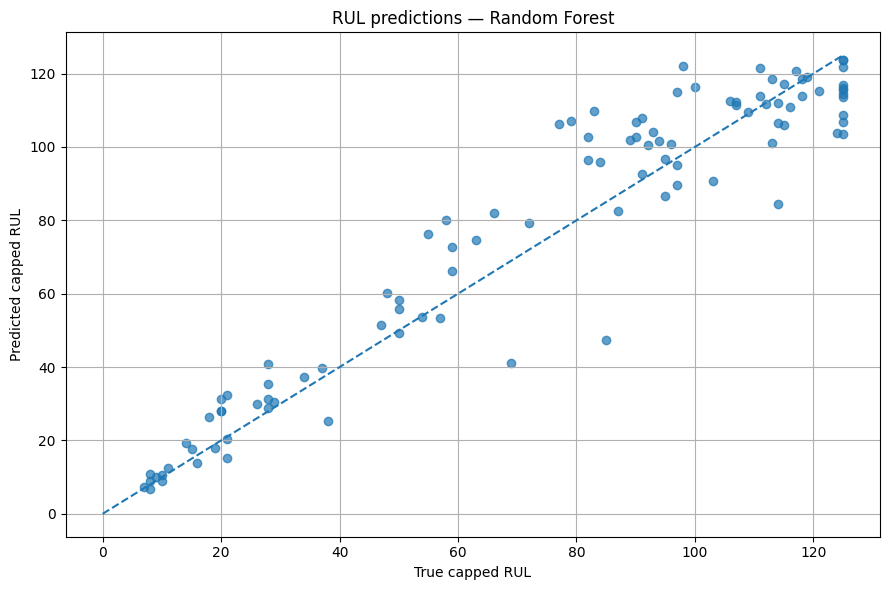

In [ ]:
# Scatter plot for best model
best_clean_model = clean_results.iloc[0]["Model"]

best_prediction_data = prediction_results[
    prediction_results["Model"] == best_clean_model
]

plt.figure(figsize=(9, 6))
plt.scatter(
    best_prediction_data["True_RUL"],
    best_prediction_data["Predicted_RUL"],
    alpha=0.70,
)

line_maximum = max(
    best_prediction_data["True_RUL"].max(),
    best_prediction_data["Predicted_RUL"].max(),
)

plt.plot([0, line_maximum], [0, line_maximum], "--")

plt.xlabel("True capped RUL")
plt.ylabel("Predicted capped RUL")
plt.title(f"RUL predictions — {best_clean_model}")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIG / "rq1_best_model_true_vs_predicted_rul.png",
    dpi=300,
)

plt.show()

## RQ2 - Controlled Temporal Corruption Protocol

This section implements the full temporal corruption‑robustness protocol for RQ2.

The goal is to quantify how each RUL model retains accuracy under controlled degradations of sensor time‑series windows. All corruptions operate on **standardised windows**, meaning:
- Zero replacement corresponds to the training mean.
- Severity levels are expressed relative to the standardised scale.

Five corruption types are evaluated:

1. **Gaussian Noise** — additive noise in standard‑deviation units  
2. **Missing Block** — contiguous block replaced with zeros  
3. **Outliers** — sparse ±4σ impulses  
4. **Gradual Offset Drift** — linear drift across the window  
5. **Sensor Freezing** — final portion of a sensor held constant

For each corruption type:
- Multiple severity levels are tested  
- Each severity is repeated 5 times with deterministic seeds  
- All models are evaluated on the same corrupted windows  
- RMSE retention, MAE retention, and NASA score inflation are computed  
- Condition‑level AUC summaries are produced  
- A composite corruption‑robustness score is generated

This section produces the robustness tables used in RQ1, RQ2, and RQ3.


In [ ]:
# Corruption severity levels for each condition
CORRUPTION_LEVELS = {
    "Gaussian_Noise": [0.05, 0.10, 0.20, 0.30],
    "Missing_Block":  [0.05, 0.10, 0.20, 0.30],
    "Outliers":       [0.01, 0.03, 0.05, 0.10],
    "Gradual_Offset_Drift": [0.05, 0.10, 0.20, 0.30],
    "Sensor_Freezing": [0.10, 0.20, 0.30, 0.40],
}

# Assign numeric IDs for deterministic corruption seeds
CONDITION_IDS = {
    condition: index
    for index, condition in enumerate(CORRUPTION_LEVELS, start=1)
}

# Corruption function
def corrupt_sequences(X_input, condition, level, rng):
    """
    Apply a temporal corruption to a batch of windows.

    Parameters:
        X_input  — (N, WINDOW, F) standardised windows
        condition — corruption type
        level     — severity level
        rng       — deterministic random generator

    Returns:
        corrupted — corrupted windows (same shape)
    """
    corrupted = X_input.copy()
    sample_count, time_steps, feature_count = corrupted.shape

    # Gaussian Noise
    if condition == "Gaussian_Noise":
        corrupted += rng.normal(
            0.0,
            level,
            size=corrupted.shape,
        ).astype(np.float32)

    # Missing Block
    elif condition == "Missing_Block":
        block_length = max(1, int(round(time_steps * level)))

        for sample_index in range(sample_count):
            feature_index = int(rng.integers(feature_count))
            start_index = int(
                rng.integers(0, max(1, time_steps - block_length + 1))
            )
            corrupted[
                sample_index,
                start_index:start_index + block_length,
                feature_index,
            ] = 0.0

    # Outliers
    elif condition == "Outliers":
        outlier_count = max(
            1,
            int(round(sample_count * time_steps * feature_count * level)),
        )

        flat = corrupted.reshape(-1)
        selected = rng.choice(len(flat), size=outlier_count, replace=False)
        directions = rng.choice([-1.0, 1.0], size=outlier_count)

        flat[selected] += directions * 4.0
        corrupted = flat.reshape(corrupted.shape)

    # Gradual Offset Drift
    elif condition == "Gradual_Offset_Drift":
        selected_feature_count = max(1, feature_count // 4)
        selected_features = rng.choice(
            feature_count,
            size=selected_feature_count,
            replace=False,
        )

        drift = np.linspace(
            0.0,
            level * 3.0,
            time_steps,
            dtype=np.float32,
        )

        corrupted[:, :, selected_features] += drift[None, :, None]

    # Sensor Freezing
    elif condition == "Sensor_Freezing":
        freeze_length = max(1, int(round(time_steps * level)))
        freeze_start = time_steps - freeze_length

        for sample_index in range(sample_count):
            feature_index = int(rng.integers(feature_count))
            frozen_value = corrupted[sample_index, freeze_start, feature_index]
            corrupted[sample_index, freeze_start:, feature_index] = frozen_value

    else:
        raise ValueError(f"Unsupported corruption condition: {condition}")

    return corrupted.astype(np.float32)

In [ ]:
# Precompute corrupted test sets for all models
corrupted_test_sets = {}

for condition, levels in CORRUPTION_LEVELS.items():
    for level in levels:
        for repeat in range(CORRUPTION_REPEATS):

            # Deterministic corruption seed
            corruption_seed = (
                PRIMARY_SEED * 1_000_000
                + CONDITION_IDS[condition] * 100_000
                + repeat * 1_000
                + int(level * 10_000)
            )

            corruption_rng = np.random.default_rng(corruption_seed)

            corrupted_test_sets[(condition, level, repeat)] = corrupt_sequences(
                Xte,
                condition,
                level,
                corruption_rng,
            )

print("Corrupted test sets prepared:", len(corrupted_test_sets))

Corrupted test sets prepared: 100


In [ ]:
# Evaluate all models under all corruptions
robustness_rows = []

for model_name, model_record in candidate_models.items():
    model = model_record["model"]

    # Prediction function depends on model type
    if model_record["type"] == "tabular_summary":
        def prediction_function(X_input, fitted_model=model):
            return fitted_model.predict(sequence_summary(X_input))
    else:
        def prediction_function(X_input, fitted_model=model):
            return fitted_model.predict(X_input, verbose=0).reshape(-1)

    # Clean baseline metrics
    clean_metrics = regression_metrics(yte, test_predictions[model_name])

    # Evaluate corrupted windows
    for (condition, level, repeat), corrupted_X in corrupted_test_sets.items():

        corrupted_prediction = np.clip(
            prediction_function(corrupted_X),
            0,
            RUL_CAP,
        )

        corrupted_metrics = regression_metrics(yte, corrupted_prediction)

        robustness_rows.append({
            "Model": model_name,
            "Condition": condition,
            "Level": level,
            "Repeat": repeat,
            **corrupted_metrics,
            "RMSE_Retention": clean_metrics["RMSE"] / max(corrupted_metrics["RMSE"], 1e-12),
            "MAE_Retention": clean_metrics["MAE"] / max(corrupted_metrics["MAE"], 1e-12),
            "NASA_Score_Inflation": corrupted_metrics["NASA_Score"] / max(clean_metrics["NASA_Score"], 1e-12),
        })

# Save raw robustness results
robustness_raw = pd.DataFrame(robustness_rows)

robustness_raw.to_csv(
    OUT / "02_robustness_raw.csv",
    index=False,
)

display(robustness_raw.head())

,Model,Condition,Level,Repeat,RMSE,MAE,NASA_Score,RMSE_Retention,MAE_Retention,NASA_Score_Inflation
0,Ridge,Gaussian_Noise,0.05,0,16.121601,12.995780,436.170498,1.007470,1.009615,0.955786
1,Ridge,Gaussian_Noise,0.05,1,16.264628,13.104851,444.682004,0.998610,1.001212,0.974438
2,Ridge,Gaussian_Noise,0.05,2,16.158579,13.007114,443.477825,1.005164,1.008735,0.971799
3,Ridge,Gaussian_Noise,0.05,3,16.086399,12.987902,437.721989,1.009674,1.010227,0.959186
4,Ridge,Gaussian_Noise,0.05,4,16.059074,12.946434,437.063967,1.011392,1.013463,0.957744


In [ ]:
# Aggregate by severity level
robustness_by_level = (
    robustness_raw
    .groupby(["Model", "Condition", "Level"], as_index=False)
    .agg(
        RMSE_Retention=("RMSE_Retention", "mean"),
        RMSE_Retention_Std=("RMSE_Retention", "std"),
        MAE_Retention=("MAE_Retention", "mean"),
        MAE_Retention_Std=("MAE_Retention", "std"),
        NASA_Score_Inflation=("NASA_Score_Inflation", "mean"),
        NASA_Score_Inflation_Std=("NASA_Score_Inflation", "std"),
    )
)

# Condition-level AUC summaries
condition_area_rows = []

for (model_name, condition), group in robustness_by_level.groupby(["Model", "Condition"]):
    group = group.sort_values("Level")

    normalised_severity = np.r_[0.0, group["Level"].to_numpy() / group["Level"].max()]
    rmse_retention = np.r_[1.0, group["RMSE_Retention"].to_numpy()]
    mae_retention = np.r_[1.0, group["MAE_Retention"].to_numpy()]
    nasa_inflation = np.r_[1.0, group["NASA_Score_Inflation"].to_numpy()]

    condition_area_rows.append({
        "Model": model_name,
        "Condition": condition,
        "RMSE_Retention_AUC": float(np.trapezoid(rmse_retention, normalised_severity)),
        "MAE_Retention_AUC": float(np.trapezoid(mae_retention, normalised_severity)),
        "NASA_Inflation_AUC": float(np.trapezoid(nasa_inflation, normalised_severity)),
        "Worst_RMSE_Retention": float(rmse_retention.min()),
    })

condition_robustness = pd.DataFrame(condition_area_rows)

# Composite corruption-robustness score
composite_robustness = (
    condition_robustness
    .groupby("Model", as_index=False)
    .agg(
        Composite_Corruption_Robustness_Mean=("RMSE_Retention_AUC", "mean"),
        Composite_MAE_Robustness_Mean=("MAE_Retention_AUC", "mean"),
        Mean_NASA_Inflation_AUC=("NASA_Inflation_AUC", "mean"),
        Worst_Condition_Retention=("Worst_RMSE_Retention", "min"),
    )
)

robustness_by_level.to_csv(
    OUT / "03_robustness_by_level.csv",
    index=False,
)

condition_robustness.to_csv(
    OUT / "04_condition_robustness.csv",
    index=False,
)

composite_robustness.to_csv(
    OUT / "05_composite_robustness.csv",
    index=False,
)

display(
    composite_robustness.sort_values(
        "Composite_Corruption_Robustness_Mean",
        ascending=False,
    )
)

,Model,Composite_Corruption_Robustness_Mean,Composite_MAE_Robustness_Mean,Mean_NASA_Inflation_AUC,Worst_Condition_Retention
1,LSTM,0.934863,0.944501,1.312769,0.652422
0,GRU,0.911314,0.918809,1.366938,0.539027
4,XGBoost,0.899531,0.891625,1.403876,0.491787
2,Random Forest,0.873915,0.868190,1.839401,0.439298
3,Ridge,0.860158,0.863416,33.396068,0.207671


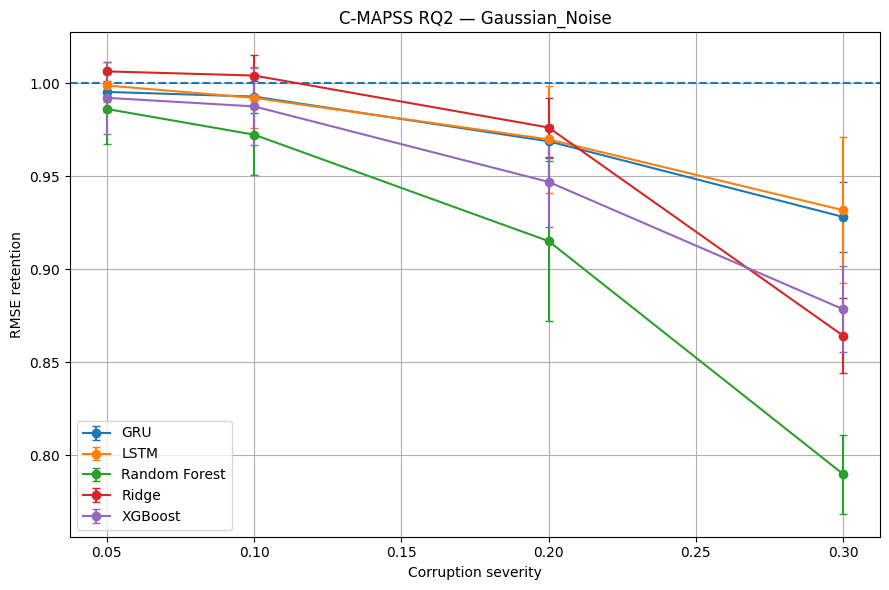

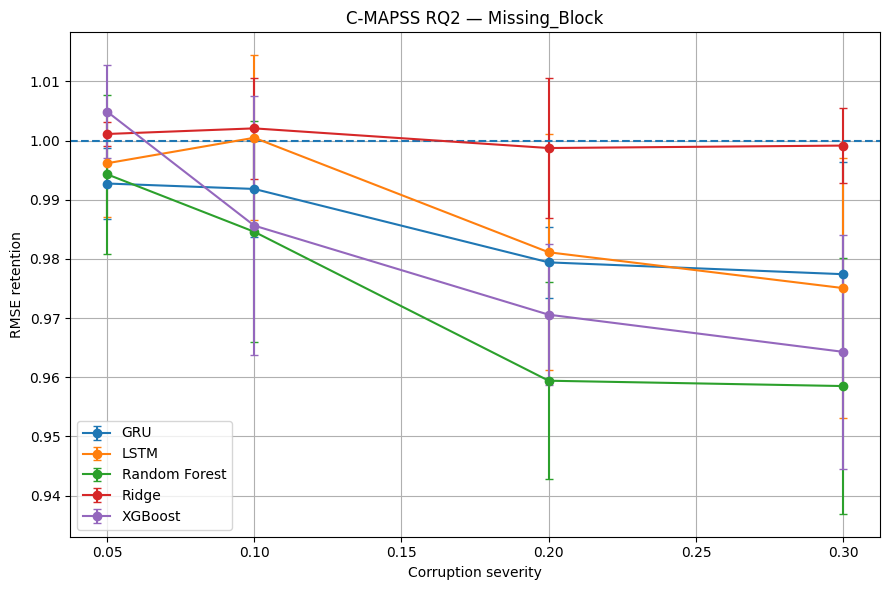

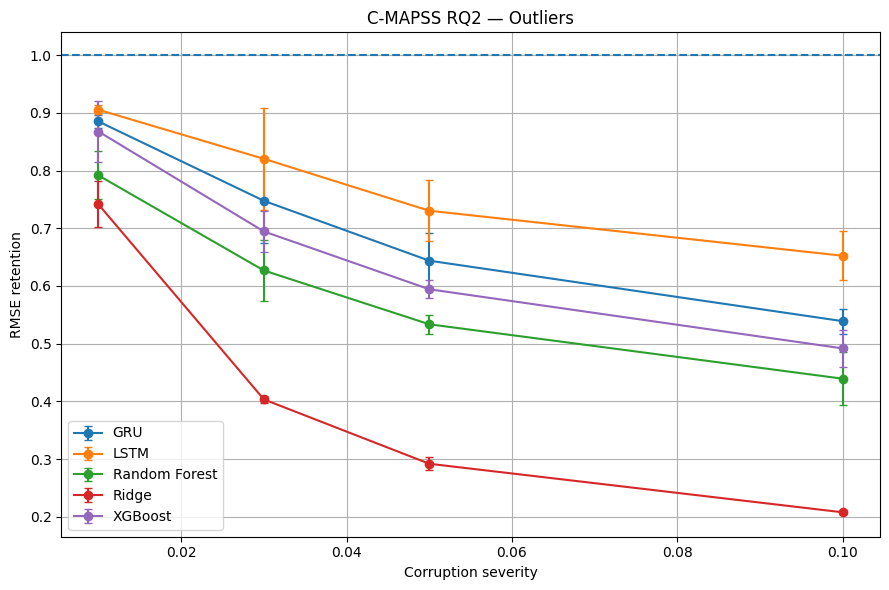

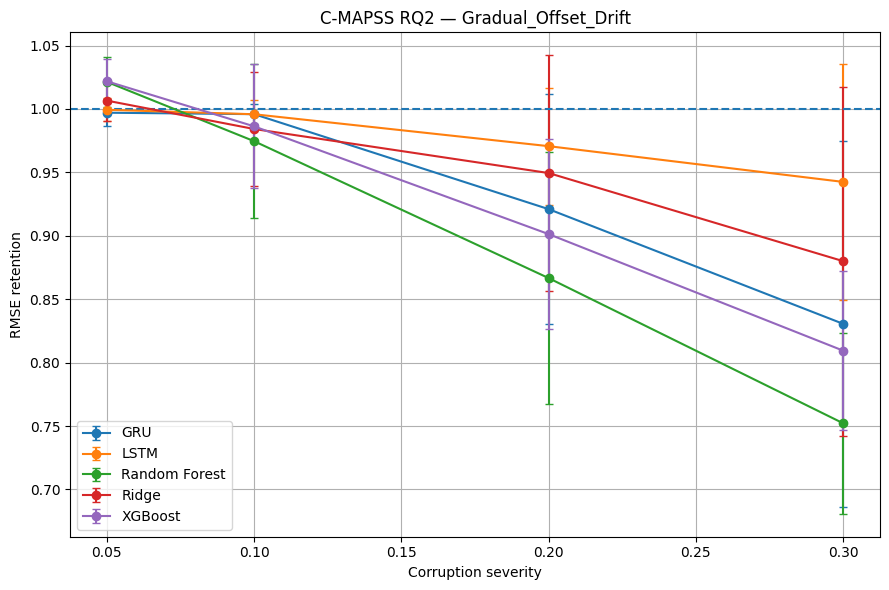

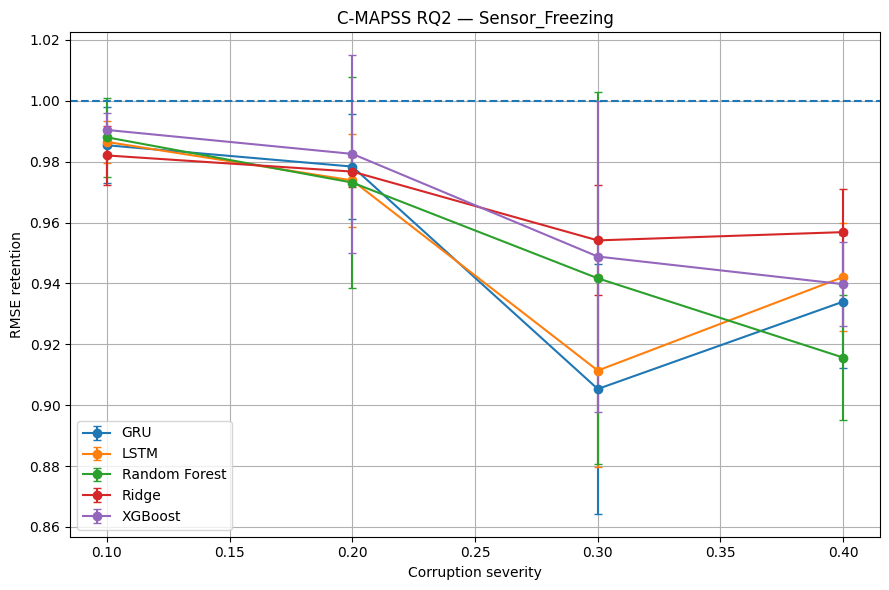

In [ ]:
# Condition-specific retention plots
for condition in CORRUPTION_LEVELS:
    plt.figure(figsize=(9, 6))

    condition_data = robustness_by_level[
        robustness_by_level["Condition"] == condition
    ]

    for model_name, group in condition_data.groupby("Model"):
        group = group.sort_values("Level")
        plt.errorbar(
            group["Level"],
            group["RMSE_Retention"],
            yerr=group["RMSE_Retention_Std"],
            marker="o",
            capsize=3,
            label=model_name,
        )

    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Corruption severity")
    plt.ylabel("RMSE retention")
    plt.title(f"C-MAPSS RQ2 — {condition}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIG / f"rq2_{condition.lower()}_retention.png",
        dpi=300,
    )

    plt.show()

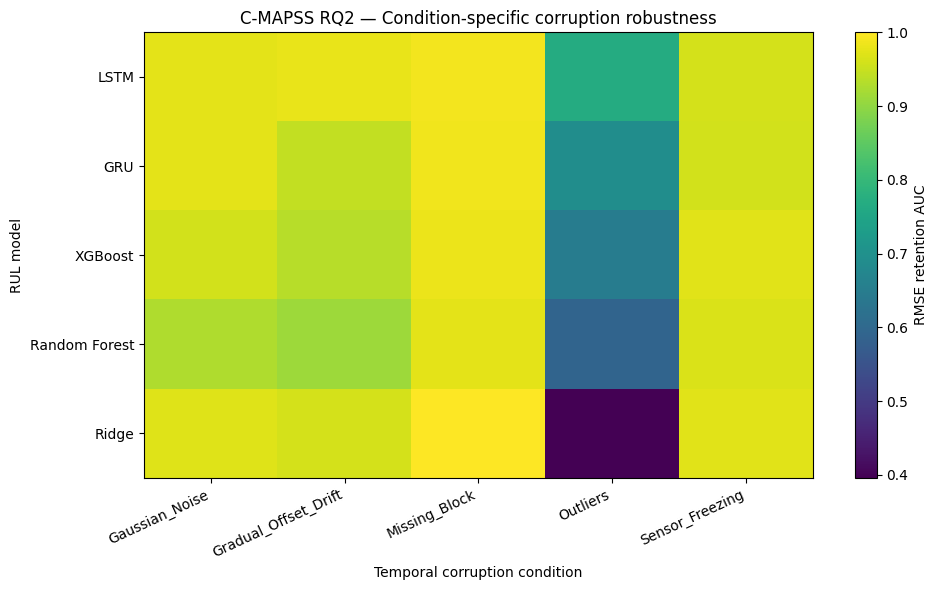

In [ ]:
# Overall robustness heatmap
condition_heatmap = (
    condition_robustness
    .pivot(index="Model", columns="Condition", values="RMSE_Retention_AUC")
)

model_order = (
    composite_robustness
    .sort_values("Composite_Corruption_Robustness_Mean", ascending=False)["Model"]
)

condition_heatmap = condition_heatmap.reindex(model_order)

plt.figure(figsize=(10, 6))
image = plt.imshow(condition_heatmap.to_numpy(), aspect="auto")
plt.colorbar(image, label="RMSE retention AUC")

plt.xticks(
    range(len(condition_heatmap.columns)),
    condition_heatmap.columns,
    rotation=25,
    ha="right",
)

plt.yticks(
    range(len(condition_heatmap.index)),
    condition_heatmap.index,
)

plt.xlabel("Temporal corruption condition")
plt.ylabel("RUL model")
plt.title("C-MAPSS RQ2 — Condition-specific corruption robustness")
plt.tight_layout()

plt.savefig(
    FIG / "rq2_overall_robustness_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### RQ1 - Conventional vs Deployment‑Oriented Baseline Ranking

This section constructs the full RQ1 baseline comparison between:

#### **Conventional evaluation**
Based solely on predictive accuracy:
- RMSE  
- MAE  
- NASA Score  

These metrics are ranked and averaged to produce a **Conventional Mean Rank** and **Conventional Winner**.

#### **Deployment‑oriented baseline**
Extends conventional evaluation by incorporating:
- **Predictive Score** (normalised RMSE, MAE, NASA Score)  
- **Robustness Score** (composite corruption‑robustness from RQ2)  
- **Efficiency Score** (single‑sample latency + model size)

These three dimensions are averaged to produce a **Deployment Baseline Score** and **Deployment Baseline Winner**.

Finally:
- Rank changes between conventional and deployment‑oriented rankings are computed.  
- Spearman and Kendall rank correlations quantify agreement between the two ranking systems.

This section produces:
- 06_candidate_summary.csv
- 07_rq1_summary.csv
which are used in RQ1, RQ2 interpretation, and RQ3 constraint‑aware selection.


In [ ]:
# Merge clean results with composite robustness
candidate_summary = (
    clean_results
    .merge(
        composite_robustness,
        on="Model",
        how="left",
    )
)

# Min–max normalisation helpers
def minmax_benefit(series):
    """
    Normalise a metric where higher values are better.
    Example: robustness AUC.
    """
    values = pd.Series(series, dtype=float)
    minimum = values.min()
    maximum = values.max()

    # Avoid division by zero when all values are identical
    if np.isclose(minimum, maximum):
        return pd.Series(np.ones(len(values)), index=values.index)

    return (values - minimum) / (maximum - minimum)

def minmax_cost(series):
    """
    Normalise a metric where lower values are better.
    Example: RMSE, MAE, NASA score, latency, model size.
    """
    return 1.0 - minmax_benefit(series)

# Conventional ranking (RMSE, MAE, NASA Score)
for metric in ["RMSE", "MAE", "NASA_Score"]:
    candidate_summary[f"{metric}_Rank"] = candidate_summary[metric].rank(
        ascending=True,
        method="average",
    )

candidate_summary["Conventional_Mean_Rank"] = candidate_summary[
    ["RMSE_Rank", "MAE_Rank", "NASA_Score_Rank"]
].mean(axis=1)

candidate_summary["Conventional_Rank"] = candidate_summary["Conventional_Mean_Rank"].rank(
    ascending=True,
    method="min",
).astype(int)

# Deployment-oriented predictive score
candidate_summary["Predictive_Score"] = (
    minmax_cost(candidate_summary["RMSE"]) +
    minmax_cost(candidate_summary["MAE"])+
    minmax_cost(candidate_summary["NASA_Score"])
) / 3

# Deployment-oriented robustness score
candidate_summary["Robustness_Score"] = minmax_benefit(
    candidate_summary["Composite_Corruption_Robustness_Mean"]
)

# Deployment-oriented efficiency score
candidate_summary["Efficiency_Score"] = (
    minmax_cost(candidate_summary["Single_Sample_Latency_Median_ms"]) +
    minmax_cost(candidate_summary["Model_Size_MB"])
) / 2

# Deployment baseline score (Predictive + Robustness + Efficiency)
candidate_summary["Deployment_Baseline_Score"] = candidate_summary[
    ["Predictive_Score", "Robustness_Score", "Efficiency_Score"]
].mean(axis=1)

candidate_summary["Deployment_Baseline_Rank"] = candidate_summary[
    "Deployment_Baseline_Score"
].rank(
    ascending=False,   # higher score is better
    method="min",
).astype(int)

# Rank change between conventional and deployment-oriented rankings
candidate_summary["Rank_Change_Deployment_Minus_Conventional"] = (
    candidate_summary["Deployment_Baseline_Rank"] - candidate_summary["Conventional_Rank"])

# Rank correlation between ranking systems
spearman_rho, spearman_p = spearmanr(
    candidate_summary["Conventional_Rank"],
    candidate_summary["Deployment_Baseline_Rank"],
)

kendall_tau, kendall_p = kendalltau(
    candidate_summary["Conventional_Rank"],
    candidate_summary["Deployment_Baseline_Rank"],
)

# Save candidate summary
candidate_summary.to_csv(
    OUT / "06_candidate_summary.csv",
    index=False,
)

# RQ1 summary table
rq1_summary = pd.DataFrame([
    {
        "Conventional_Winner": candidate_summary.sort_values("Conventional_Rank").iloc[0]["Model"],
        "Deployment_Baseline_Winner": candidate_summary.sort_values("Deployment_Baseline_Rank").iloc[0]["Model"],
        "Spearman_Rho": spearman_rho,
        "Spearman_p": spearman_p,
        "Kendall_Tau": kendall_tau,
        "Kendall_p": kendall_p,
    }
])

rq1_summary.to_csv(
    OUT / "07_rq1_summary.csv",
    index=False,
)

display(candidate_summary.sort_values("Deployment_Baseline_Rank"))
display(rq1_summary)

,Model,Training_Time_Seconds,Epochs_Trained,Model_Size_MB,Batch_Latency_Median_ms,Batch_Latency_P95_ms,Latency_Per_Sample_Median_ms,Throughput_Samples_Per_Second,Single_Sample_Latency_Median_ms,Single_Sample_Latency_P95_ms,...,MAE_Rank,NASA_Score_Rank,Conventional_Mean_Rank,Conventional_Rank,Predictive_Score,Robustness_Score,Efficiency_Score,Deployment_Baseline_Score,Deployment_Baseline_Rank,Rank_Change_Deployment_Minus_Conventional
1,XGBoost,2.770726,NaN,0.515448,1.614822,1.755478,0.016148,61926.329962,0.684253,2.792220,...,2.0,2.0,2.000000,2,0.955677,0.527053,0.997179,0.826636,1,-1
3,LSTM,20.090268,19.0,0.294238,115.554157,140.328476,1.155542,865.395093,73.595436,88.338198,...,3.0,4.0,3.666667,4,0.554694,1.000000,0.738602,0.764432,2,-2
2,GRU,30.258009,32.0,0.236370,116.901450,141.192949,1.169015,855.421383,74.589205,82.942907,...,4.0,3.0,3.333333,3,0.575284,0.684778,0.735216,0.665093,3,0
0,Random Forest,486.389331,NaN,197.846559,148.736705,152.021442,1.487367,672.329001,140.937667,152.681506,...,1.0,1.0,1.000000,1,1.000000,0.184153,0.000000,0.394718,4,3
4,Ridge,0.083586,NaN,0.000783,0.840750,1.088665,0.008407,118941.421357,0.256516,0.316908,...,5.0,5.0,5.000000,5,0.000000,0.000000,1.000000,0.333333,5,0


,Conventional_Winner,Deployment_Baseline_Winner,Spearman_Rho,Spearman_p,Kendall_Tau,Kendall_p
0,Random Forest,XGBoost,0.3,0.623838,0.2,0.816667


## RQ1 - Conventional vs Deployment‑Oriented Ranking Comparison

This section visualises the ranking differences between:

- **Conventional ranking**  
  Based solely on RMSE, MAE, NASA Score.

- **Deployment‑oriented baseline ranking**  
  Based on Predictive Score, Robustness Score, and Efficiency Score.

The plot shows:
- Each model ordered by its **Conventional Rank**  
- Two lines:
  - Conventional Rank  
  - Deployment‑Oriented Baseline Rank  
- Rank shifts highlight models whose deployment suitability differs from their pure predictive accuracy.

This figure is used in RQ1 discussion and RQ3 justification.


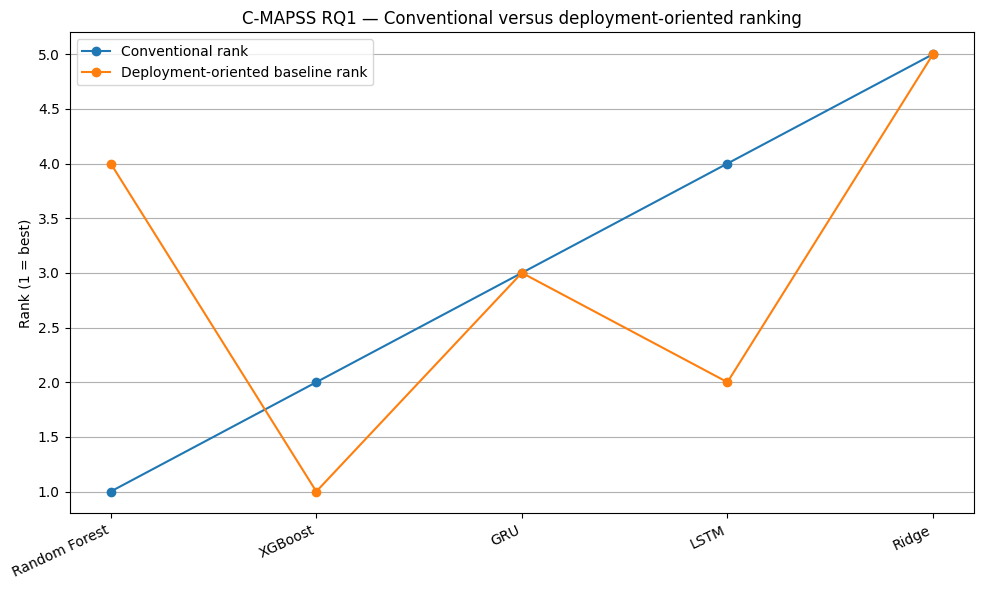

In [ ]:
# Sort models by conventional rank
rank_plot = candidate_summary.sort_values("Conventional_Rank")

# X-axis positions for plotting
x_positions = np.arange(len(rank_plot))

plt.figure(figsize=(10, 6))

# Plot conventional ranking
plt.plot(
    x_positions,
    rank_plot["Conventional_Rank"],
    marker="o",
    label="Conventional rank",
)

# Plot deployment-oriented ranking
plt.plot(
    x_positions,
    rank_plot["Deployment_Baseline_Rank"],
    marker="o",
    label="Deployment-oriented baseline rank",
)

# X-axis labels (model names)
plt.xticks(
    x_positions,
    rank_plot["Model"],
    rotation=25,
    ha="right",
)

plt.ylabel("Rank (1 = best)")
plt.title("C-MAPSS RQ1 — Conventional versus deployment-oriented ranking")

plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG / "rq1_ranking_comparison.png",
    dpi=300,
)

plt.show()

##11. RQ3  Pareto‑Efficient Model Identification

This section identifies **Pareto‑efficient RUL models** across five deployment‑relevant objectives:

| Objective | Direction | Meaning |
|----------|-----------|---------|
| RMSE | min | Lower prediction error is better |
| Composite Corruption Robustness Mean | max | Higher robustness is better |
| Single‑Sample Latency Median | min | Faster inference is better |
| NASA Score | min | Lower asymmetric penalty is better |
| Model Size (MB) | min | Smaller models are better for edge deployment |

A model is **Pareto‑efficient** if no other model is strictly better in at least one objective *and* no worse in all others.

This produces:
- A boolean mask identifying Pareto‑efficient models  
- A filtered summary table  
- 08_candidate_pareto_summary.csv

These results feed directly into **RQ3 scenario‑based selection**.


In [ ]:
# Multi-objective criteria for Pareto analysis
PARETO_OBJECTIVES = {
    "RMSE": "min",
    "Composite_Corruption_Robustness_Mean": "max",
    "Single_Sample_Latency_Median_ms": "min",
    "NASA_Score": "min",
    "Model_Size_MB": "min",
}

# Dominance function
def dominates(model_a, model_b, objectives=PARETO_OBJECTIVES):
    """
    Determine whether model_a dominates model_b.

    A dominates B if:
      • A is no worse than B in all objectives
      • A is strictly better in at least one objective
    """
    no_worse = True
    strictly_better = False

    for metric, direction in objectives.items():
        value_a = float(model_a[metric])
        value_b = float(model_b[metric])

        if direction == "max":
            # Higher is better
            if value_a < value_b:
                no_worse = False
                break
            if value_a > value_b:
                strictly_better = True

        elif direction == "min":
            # Lower is better
            if value_a > value_b:
                no_worse = False
                break
            if value_a < value_b:
                strictly_better = True

        else:
            raise ValueError(f"Unsupported direction: {direction}")

    return no_worse and strictly_better

# Pareto mask computation
def pareto_mask(dataframe, objectives=PARETO_OBJECTIVES):
    """
    Compute a boolean mask indicating which models are Pareto-efficient.
    """
    records = dataframe.reset_index(drop=True)
    efficient = np.ones(len(records), dtype=bool)

    for index_i in range(len(records)):
        if not efficient[index_i]:
            continue

        for index_j in range(len(records)):
            if (
                index_i != index_j
                and dominates(
                    records.iloc[index_j],
                    records.iloc[index_i],
                    objectives,
                )
            ):
                efficient[index_i] = False
                break

    return efficient

# Apply Pareto analysis
candidate_summary["Pareto_Efficient"] = pareto_mask(candidate_summary)

candidate_summary.to_csv(
    OUT / "08_candidate_pareto_summary.csv",
    index=False,
)

# Display Pareto-efficient models (sorted by RMSE)
display(
    candidate_summary.sort_values(
        ["Pareto_Efficient", "RMSE"],
        ascending=[False, True],
    )
)

,Model,Training_Time_Seconds,Epochs_Trained,Model_Size_MB,Batch_Latency_Median_ms,Batch_Latency_P95_ms,Latency_Per_Sample_Median_ms,Throughput_Samples_Per_Second,Single_Sample_Latency_Median_ms,Single_Sample_Latency_P95_ms,...,NASA_Score_Rank,Conventional_Mean_Rank,Conventional_Rank,Predictive_Score,Robustness_Score,Efficiency_Score,Deployment_Baseline_Score,Deployment_Baseline_Rank,Rank_Change_Deployment_Minus_Conventional,Pareto_Efficient
0,Random Forest,486.389331,NaN,197.846559,148.736705,152.021442,1.487367,672.329001,140.937667,152.681506,...,1.0,1.000000,1,1.000000,0.184153,0.000000,0.394718,4,3,True
1,XGBoost,2.770726,NaN,0.515448,1.614822,1.755478,0.016148,61926.329962,0.684253,2.792220,...,2.0,2.000000,2,0.955677,0.527053,0.997179,0.826636,1,-1,True
2,GRU,30.258009,32.0,0.236370,116.901450,141.192949,1.169015,855.421383,74.589205,82.942907,...,3.0,3.333333,3,0.575284,0.684778,0.735216,0.665093,3,0,True
3,LSTM,20.090268,19.0,0.294238,115.554157,140.328476,1.155542,865.395093,73.595436,88.338198,...,4.0,3.666667,4,0.554694,1.000000,0.738602,0.764432,2,-2,True
4,Ridge,0.083586,NaN,0.000783,0.840750,1.088665,0.008407,118941.421357,0.256516,0.316908,...,5.0,5.000000,5,0.000000,0.000000,1.000000,0.333333,5,0,True


## RQ3 - Scenario‑Based Constraint Selection

This section implements the constraint‑based selection mechanism for RQ3.

While Pareto‑efficiency (Section 11) identifies non‑dominated models across multiple objectives, scenario‑based selection introduces **explicit operational constraints**, such as:

- Minimum robustness  
- Maximum RMSE  
- Maximum latency  
- Maximum model size  

These constraints represent **experimental deployment parameters**, derived from observed candidate ranges rather than real factory requirements.

The selection procedure:

1. **apply_constraints()**  
   Filters the candidate models using inequality constraints.

2. **constrained_selection()**  
   Among feasible models:
   - Sorts by the scenario’s *primary metric*  
   - Uses remaining Pareto objectives as secondary tie‑breakers  
   - Returns the recommended model and its metrics

3. **Scenario definitions**  
   Three scenarios are evaluated:
   - Accuracy‑Focused  
   - Robustness‑Focused  
   - Latency‑Focused  

4. **Scenario recommendations table**  
   Saved as 09_scenario_recommendations.csv

This section produces the final RQ3 recommendations.


In [ ]:
# Constraint application function
def apply_constraints(dataframe, constraints):
    """
    Apply inequality constraints to candidate_summary.

    Parameters:
        dataframe   — candidate_summary DataFrame
        constraints — dict mapping metric -> (operator, threshold)

    Returns:
        Filtered DataFrame containing only models satisfying all constraints.
    """
    mask = np.ones(len(dataframe), dtype=bool)

    for metric, (operator, threshold) in constraints.items():
        if metric not in dataframe.columns:
            raise KeyError(f"Constraint metric not found: {metric}")

        if operator == ">=":
            mask &= (dataframe[metric] >= threshold).to_numpy()

        elif operator == "<=":
            mask &= (dataframe[metric] <= threshold).to_numpy()

        else:
            raise ValueError(f"Unsupported operator: {operator}")

    return dataframe[mask].copy()

# Scenario selection function
def constrained_selection(primary_metric, direction, constraints):
    """
    Select the best feasible model under scenario constraints.

    Parameters:
        primary_metric — metric to optimise (RMSE, robustness, latency)
        direction      — "min" or "max"
        constraints    — inequality constraints

    Returns:
        Dictionary containing:
            • Status
            • Number of feasible models
            • Recommended model + metrics
    """
    feasible = apply_constraints(candidate_summary, constraints)

    if feasible.empty:
        return {
            "Status": "No feasible solution",
            "N_Feasible": 0,
        }

    # Secondary metrics = remaining Pareto objectives
    secondary_metrics = [
        metric for metric in PARETO_OBJECTIVES
        if metric != primary_metric
    ]

    # Sorting order: primary metric first, then secondary metrics
    sort_columns = [primary_metric, *secondary_metrics]

    sort_ascending = [
        direction == "min",
        *[
            (PARETO_OBJECTIVES[metric] == "min")
            for metric in secondary_metrics
        ],
    ]

    winner = (
        feasible
        .sort_values(sort_columns, ascending=sort_ascending)
        .iloc[0]
    )

    return {
        "Status": "Feasible",
        "N_Feasible": len(feasible),
        "Recommended_Model": winner["Model"],
        "RMSE": winner["RMSE"],
        "MAE": winner["MAE"],
        "NASA_Score": winner["NASA_Score"],
        "Composite_Corruption_Robustness_Mean": winner["Composite_Corruption_Robustness_Mean"],
        "Single_Sample_Latency_Median_ms": winner["Single_Sample_Latency_Median_ms"],
        "Model_Size_MB": winner["Model_Size_MB"],
    }

# Scenario thresholds derived from candidate distribution
rmse_median = float(candidate_summary["RMSE"].median())
robustness_quantile = float(candidate_summary["Composite_Corruption_Robustness_Mean"].quantile(0.35))
latency_quantile = float(candidate_summary["Single_Sample_Latency_Median_ms"].quantile(0.75))

# Scenario definitions and evaluation
scenario_recommendations = pd.DataFrame([
    {
        "Scenario": "Accuracy_Focused",
        **constrained_selection(
            "RMSE",
            "min",
            {
                "Composite_Corruption_Robustness_Mean": (">=", robustness_quantile),
            },
        ),
    },
    {
        "Scenario": "Robustness_Focused",
        **constrained_selection(
            "Composite_Corruption_Robustness_Mean",
            "max",
            {
                "RMSE": ("<=", rmse_median),
            },
        ),
    },
    {
        "Scenario": "Latency_Focused",
        **constrained_selection(
            "Single_Sample_Latency_Median_ms",
            "min",
            {
                "RMSE": ("<=", rmse_median),
                "Composite_Corruption_Robustness_Mean": (">=", robustness_quantile),
                "Single_Sample_Latency_Median_ms": ("<=", latency_quantile),
            },
        ),
    },
])

# Save scenario recommendations
scenario_recommendations.to_csv(
    OUT / "09_scenario_recommendations.csv",
    index=False,
)

display(scenario_recommendations)

,Scenario,Status,N_Feasible,Recommended_Model,RMSE,MAE,NASA_Score,Composite_Corruption_Robustness_Mean,Single_Sample_Latency_Median_ms,Model_Size_MB
0,Accuracy_Focused,Feasible,3,XGBoost,12.143886,9.107116,225.737407,0.899531,0.684253,0.515448
1,Robustness_Focused,Feasible,3,GRU,13.779129,10.427896,333.042455,0.911314,74.589205,0.236370
2,Latency_Focused,Feasible,2,XGBoost,12.143886,9.107116,225.737407,0.899531,0.684253,0.515448


## Notebook 4 Summary

In [ ]:
framework_report = {
    "Dataset": FD,
    "Window_Length": WINDOW,
    "RUL_Cap": RUL_CAP,

    # Engine counts
    "Training_Engines": train_split["unit"].nunique(),
    "Validation_Engines": validation_split["unit"].nunique(),
    "Testing_Engines": test["unit"].nunique(),

    # Feature selection
    "Selected_Feature_Count": len(features),

    # RQ1 winners
    "RQ1_Conventional_Winner":
        candidate_summary.sort_values("Conventional_Rank").iloc[0]["Model"],
    "RQ1_Deployment_Baseline_Winner":
        candidate_summary.sort_values("Deployment_Baseline_Rank").iloc[0]["Model"],

    # RQ1 rank correlation
    "RQ1_Spearman_Rho": float(spearman_rho),
    "RQ1_Kendall_Tau": float(kendall_tau),

    # RQ2 best robustness model
    "RQ2_Best_Composite_Corruption_Robustness":
        composite_robustness.sort_values(
            "Composite_Corruption_Robustness_Mean",
            ascending=False,
        ).iloc[0]["Model"],
    "RQ2_Best_Composite_Corruption_Robustness_Score":
        float(
            composite_robustness.sort_values(
                "Composite_Corruption_Robustness_Mean",
                ascending=False,
            ).iloc[0]["Composite_Corruption_Robustness_Mean"]
        ),

    # RQ3 Pareto and scenario results
    "RQ3_Pareto_Efficient_Count":
        int(candidate_summary["Pareto_Efficient"].sum()),
    "RQ3_Scenario_Recommendations":
        scenario_recommendations[
            ["Scenario", "Recommended_Model"]
        ].to_dict(orient="records"),

    # Notebook 5 hand-off
    "Notebook5_Handoff": str(PROCESSED / "notebook5_handoff_manifest.json"),

    # Important limitations
    "Important_Limitations": [
        "FD001 contains one operating condition and one fault mode.",
        "Only the primary seed is executed by default.",
        "Latency is comparative software-level timing.",
        "Composite corruption robustness is an adapted summary.",
        "Scenario constraints are experimental rather than industrial requirements.",
    ],
}

# Save framework report
with open(
    OUT / "10_framework_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(framework_report, file, indent=2)

display(
    pd.DataFrame({
        "Item": list(framework_report.keys()),
        "Value": [str(value) for value in framework_report.values()],
    })
)

,Item,Value
0,Dataset,FD001
1,Window_Length,30
2,RUL_Cap,125
3,Training_Engines,80
4,Validation_Engines,20
5,Testing_Engines,100
6,Selected_Feature_Count,17
7,RQ1_Conventional_Winner,Random Forest
8,RQ1_Deployment_Baseline_Winner,XGBoost
9,RQ1_Spearman_Rho,0.3


## Final interpretation

This notebook produces a complete temporal RUL evidence base:

- **RQ1:** conventional RUL rankings and a deployment-oriented baseline ranking;
- **RQ2:** condition-specific retention curves, area-under-retention summaries, worst-condition retention and a composite secondary summary;
- **RQ3:** Pareto-efficient candidates and adaptive constraint-based scenario recommendations;
- **Notebook 5:** a reproducible saved hand-off containing `Xtr`, `ytr`, `Xv`, `yv`, `Xte` and `yte`.

For stronger final claims, the C-MAPSS stage can later be repeated across additional seeds or extended to FD003/FD004. The default version intentionally remains computationally manageable in Colab.